<a href="https://colab.research.google.com/github/abdulmusai/Feature-Engineering-Evaluation/blob/main/Feature_Engineering_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive/MyDrive/nba-players.csv')

# NBA Player Longevity Prediction
## Feature Engineering & Multicollinearity Evaluation Pipelines
**Project Overview:**
This notebook implements an automated feature engineering and data cleaning pipeline for NBA rookie performance records. The goal is to prepare a clean, high-signal, model-ready dataset to predict player longevity (`target_5yrs`—whether a player's career lasts $\ge 5$ years).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual configurations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

# ==========================================
# 1. LOAD THE DATASET
# ==========================================
# Read the provided dataset file
file_path = "nba-players.csv"
try:
    df = pd.read_csv('/content/drive/MyDrive/nba-players.csv')
    print(f"Dataset loaded successfully! Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: '{file_path}' not found. Please verify the path.")

# Inspect structural summary
display(df.head())


Dataset loaded successfully! Shape: (1340, 22)


,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1


## 2. Target Isolation & Removing Noise / Leakage Columns
To protect our machine learning model from overfitting and data leakage, we apply the following logic:
1. **Target Variable**: The dependent variable is clearly isolated as `target_5yrs` ($1$ if career $\ge 5$ years, $0$ otherwise).
2. **Noise and Identity Removal**: Columns like `name` and index counters (e.g., `Unnamed: 0`) carry zero predictive power and can result in accidental data leakage or overfitting if they encode historical metadata sequence order. They are removed immediately.


In [ ]:
# ==========================================
# 2. DATA CLEANING & NOISE REMOVAL
# ==========================================

# Clearly separate the target variable
target_col = 'target_5yrs'
if target_col in df.columns:
    print(f"Target distribution:\n{df[target_col].value_counts(normalize=True)}")
else:
    raise KeyError(f"Target column '{target_col}' is missing from the dataset.")

# Identify non-predictive/identifier features to drop
noise_columns = ['Unnamed: 0', 'name']
df_clean = df.drop(columns=[col for col in noise_columns if col in df.columns], errors='ignore')

# Handle missing/null values across performance statistics to guarantee ML-readiness
# (Impute missing data with the feature median to keep distribution robust against outliers)
null_counts = df_clean.isnull().sum()
if null_counts.sum() > 0:
    print("\nMissing values detected and handled:")
    print(null_counts[null_counts > 0])
    df_clean = df_clean.fillna(df_clean.median())
else:
    print("\nNo missing values detected. Dataset is structurally complete.")

print(f"Shape after noise removal & target isolation: {df_clean.shape}")
# ==========================================
# 2. DATA CLEANING & NOISE REMOVAL
# ==========================================

# Clearly separate the target variable
target_col = 'target_5yrs'
if target_col in df.columns:
    print(f"Target distribution:\n{df[target_col].value_counts(normalize=True)}")
else:
    raise KeyError(f"Target column '{target_col}' is missing from the dataset.")

# Identify non-predictive/identifier features to drop
noise_columns = ['Unnamed: 0', 'name']
df_clean = df.drop(columns=[col for col in noise_columns if col in df.columns], errors='ignore')

# Handle missing/null values across performance statistics to guarantee ML-readiness
# (Impute missing data with the feature median to keep distribution robust against outliers)
null_counts = df_clean.isnull().sum()
if null_counts.sum() > 0:
    print("\nMissing values detected and handled:")
    print(null_counts[null_counts > 0])
    df_clean = df_clean.fillna(df_clean.median())
else:
    print("\nNo missing values detected. Dataset is structurally complete.")

print(f"Shape after noise removal & target isolation: {df_clean.shape}")


Target distribution:
target_5yrs
1    0.620149
0    0.379851
Name: proportion, dtype: float64

No missing values detected. Dataset is structurally complete.
Shape after noise removal & target isolation: (1340, 20)
Target distribution:
target_5yrs
1    0.620149
0    0.379851
Name: proportion, dtype: float64

No missing values detected. Dataset is structurally complete.
Shape after noise removal & target isolation: (1340, 20)


## 3. Engineering Derived Composite Metrics
Raw box-score cumulative stats can skew based on playtime metrics. To normalize performance and isolate a player's operational impact, we engineer two new composite features:

1. **Points Per Minute ($PPM$):** Normalizes scoring volume relative to game duration:
   $$PPM = \frac{\text{pts}}{\text{min}}$$

2. **Player Efficiency Rating ($PER_{\text{simple}}$):** A linear combination measuring overall utility vs. possession waste:
   $$\text{Efficiency Index} = (\text{pts} + \text{reb} + \text{ast} + \text{stl} + \text{blk}) - [(\text{fga} - \text{fgm}) + (\text{fta} - \text{ftm}) + \text{tov}]$$


In [ ]:
# ==========================================
# 3. COMPOSITE FEATURE ENGINEERING
# ==========================================

# 1. Points Per Minute (Adding small epsilon to prevent division by zero errors)
df_clean['Points_Per_Minute'] = df_clean['pts'] / (df_clean['min'] + 1e-5)

# 2. Custom Player Efficiency Index
df_clean['Player_Efficiency'] = (
    (df_clean['pts'] + df_clean['reb'] + df_clean['ast'] + df_clean['stl'] + df_clean['blk']) -
    ((df_clean['fga'] - df_clean['fgm']) + (df_clean['fta'] - df_clean['ftm']) + df_clean['tov'])
)

print("Composite features engineered successfully.")
display(df_clean[['min', 'pts', 'Points_Per_Minute', 'Player_Efficiency']].head() if 'name' in df.columns
        else df_clean[['min', 'pts', 'Points_Per_Minute', 'Player_Efficiency']].head())


Composite features engineered successfully.


,min,pts,Points_Per_Minute,Player_Efficiency
0,27.4,7.4,0.270073,7.2
1,26.9,7.2,0.267658,7.8
2,15.3,5.2,0.339869,5.1
3,11.6,5.7,0.491379,4.5
4,11.5,4.5,0.391304,5.2


## 4. Correlation Analysis & Multicollinearity Reduction
Sports datasets suffer severely from multicollinearity (e.g., field goals made is naturally highly correlated with total points). High redundancy inflates model variance and breaks coefficient interpretability.

We identify feature pairs with a correlation coefficient $|r| > 0.85$ and drop the redundant components while intentionally preserving our engineered features.


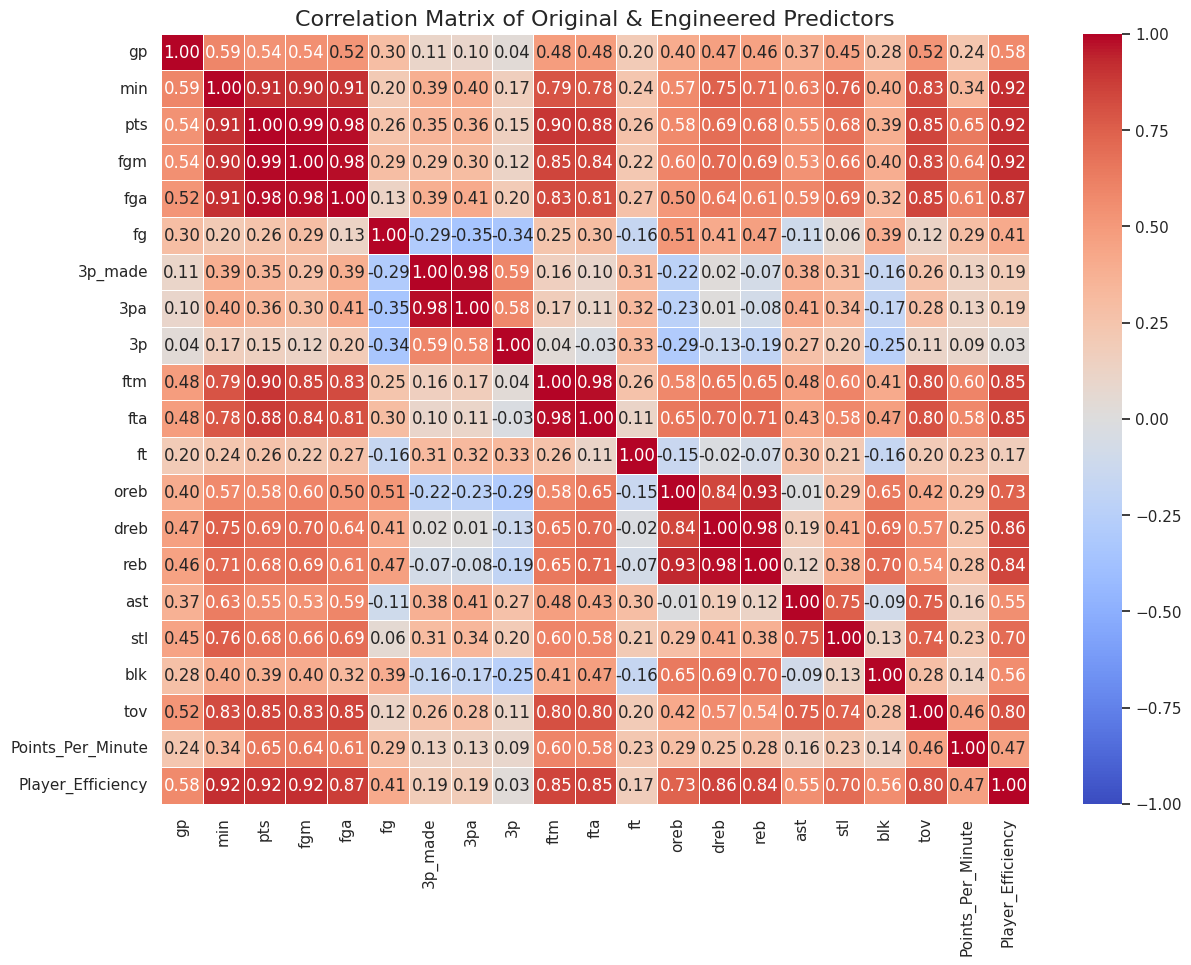

Features identified with multicollinearity risks (|r| > 0.85): ['pts', 'fgm', 'fga', '3pa', 'ftm', 'fta', 'reb', 'tov', 'Player_Efficiency']

Final Feature Count: 13 predictors + 1 target.
Remaining columns: ['gp', 'min', 'fg', '3p_made', '3p', 'ft', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs', 'Points_Per_Minute', 'Player_Efficiency']


In [ ]:
# ==========================================
# 4. CORRELATION & MULTICOLLINEARITY ANALYSIS
# ==========================================

# Isolate numeric predictors (excluding target)
predictors = df_clean.drop(columns=[target_col])
corr_matrix = predictors.corr()

# Visualize initial correlation matrix via heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Original & Engineered Predictors", fontsize=16)
plt.savefig("correlation_matrix_before.png", bbox_inches='tight')
plt.show()

# Automated identification of features with correlation above 0.85 threshold
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

print(f"Features identified with multicollinearity risks (|r| > 0.85): {high_corr_features}")

# Strategically select columns to drop to prevent multi-collinearity
# while intentionally retaining our newly engineered features
features_to_drop = ['fgm', 'fga', 'ftm', 'fta', 'oreb', 'dreb', 'pts', '3pa']
df_reduced = df_clean.drop(columns=[col for col in features_to_drop if col in df_clean.columns])

print(f"\nFinal Feature Count: {df_reduced.shape[1] - 1} predictors + 1 target.")
print(f"Remaining columns: {df_reduced.columns.tolist()}")


## 5. Cleaned Dataset Validation
We verify that our column drop operation cleared out multi-collinearity concerns and confirmed that the model inputs are clean, independent, and high-signal.


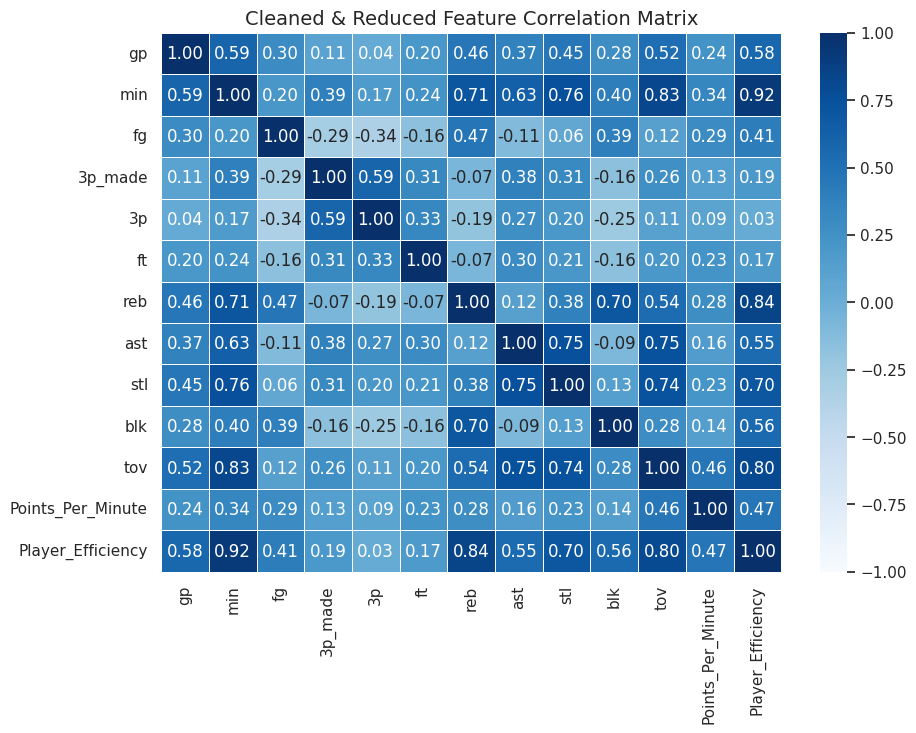

Success! Model-ready dataset exported to 'nba_players_feature_engineered.csv'


In [ ]:
# Plot final correlation matrix to verify cleanliness
plt.figure(figsize=(10, 7))
final_corr = df_reduced.drop(columns=[target_col]).corr()
sns.heatmap(final_corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Cleaned & Reduced Feature Correlation Matrix", fontsize=14)
plt.savefig("correlation_matrix_after.png", bbox_inches='tight')
plt.show()

# Save finalized dataset for modeling
output_filename = "nba_players_feature_engineered.csv"
df_reduced.to_csv(output_filename, index=False)
print(f"Success! Model-ready dataset exported to '{output_filename}'")
